# Robust Linear Regression Under Outliers

This reproducible notebook accompanies the Towards Data Science article
**“How to Make Linear Regression Survive Outliers.”** It implements the
six estimators, runs the Monte Carlo experiments, exports the numerical
summaries, and generates the nine PNG figures used in the article.

Two competing-line settings are intentionally kept separate:

- **Introductory illustration:** the alternative line has the actual
  slope \(9\). It is used only to visually demonstrate how contaminated
  observations can pull an OLS fit.
- **Structured benchmark:** the alternative slope is five times the
  nominal slope \(3\), giving the actual slope \(15\). This is the
  coherent competing model used in the quantitative experiments.

All random experiments use deterministic seeds. Runtime measurements
remain hardware- and software-dependent, so they should be interpreted
primarily through relative ordering and scaling trends.

The article figures use consistent typography, method order, colors,
and legend labels. The two introductory plots use the same vertical-axis
limits; extreme contaminated observations outside that common range are
therefore clipped.


## 1. Imports and core configuration


In [1]:
from __future__ import annotations

from dataclasses import dataclass, field, replace
from pathlib import Path
from time import perf_counter
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from scipy.special import expit, gamma
from scipy.stats import chi2


In [2]:
@dataclass
class Config:
    """Core model, estimator, simulation, and output settings."""

    # --------------------------------------------------------
    # True regression model: y = intercept + slope*x + noise
    # --------------------------------------------------------
    slope: float = 3.0
    intercept: float = 20.0

    # --------------------------------------------------------
    # Fixed predictor grid
    # Increase this value to study scaling with N.
    # --------------------------------------------------------
    n_samples: int = 100
    x_min: float = -100.0
    x_max: float = 100.0

    # --------------------------------------------------------
    # Nominal Gaussian noise
    # --------------------------------------------------------
    nominal_mean: float = 0.0
    nominal_variance: float = 1000.0

    # --------------------------------------------------------
    # Contamination model
    # "replacement_noise": corrupted responses remain around
    # the nominal line but use Gaussian or uniform outlier noise.
    # "competing_line": corrupted responses follow a second line.
    # --------------------------------------------------------
    contamination_model: str = "replacement_noise"

    # Outlier-noise distribution for replacement-noise cases.
    outlier_distribution: str = "uniform"

    # Default competing-line parameters used only by direct calls to
    # generate_dataset(...). `competing_slope` is the actual slope,
    # not a multiplier. The retained introductory and structured
    # experiments override this base value explicitly.
    competing_intercept: float = 20.0
    competing_slope: float = 5.0

    # Gaussian outlier parameters
    outlier_gaussian_mean: float = 0.0
    outlier_gaussian_variance: float = 100_000.0

    # Uniform outlier parameters
    outlier_uniform_low: float = -100.0
    outlier_uniform_high: float = 300.0

    # --------------------------------------------------------
    # Monte Carlo experiment
    # --------------------------------------------------------
    outlier_ratios: list[float] = field(
        default_factory=lambda: [0.0, 0.1, 0.3, 0.5, 0.7, 0.9]
    )
    monte_carlo_runs: int = 30
    base_seed: int = 5000

    # Run index 0 means MC run 1.
    sample_scatter_run_index: int = 0
    evaluation_points: int = 500

    # --------------------------------------------------------
    # Compared methods
    # --------------------------------------------------------
    methods: list[str] = field(
        default_factory=lambda: [
            "OLS",
            "Huber",
            "RANSAC",
            "ASOR",
            "GNC-GM",
            "GNC-TLS",
        ]
    )

    # --------------------------------------------------------
    # Huber settings: no fixed iteration cap
    # --------------------------------------------------------
    huber_epsilon: float = 1.35
    huber_tolerance: float = 1e-5

    # --------------------------------------------------------
    # RANSAC settings: no fixed trial cap
    #
    # Unique two-point subsets are sampled without replacement.
    # The method stops when the confidence criterion is met.
    # If necessary, it can exhaust all C(N,2) subsets.
    # --------------------------------------------------------
    ransac_confidence: float = 0.999
    ransac_threshold_sigma: float = 3.0

    # --------------------------------------------------------
    # ASOR settings from Bayesian Heuristics for Robust
    # Spatial Perception: no fixed iteration cap
    # --------------------------------------------------------
    asor_a0: float = 0.5
    asor_initial_b: float = 10_000.0
    asor_prior_A: float = 10_000.0
    asor_prior_B: float = 1_000.0
    asor_theta: float = 0.5
    asor_tolerance: float = 1e-5

    # --------------------------------------------------------
    # GNC continuation settings. The 0.99 chi-square probability is a
    # benchmark calibration choice, not a prescribed value from the paper.
    # --------------------------------------------------------
    bhrsp_chi2_probability: float = 0.99
    bhrsp_residual_dof: int = 1
    gnc_division_factor: float = 1.4
    gnc_multiplication_factor: float = 1.4
    gnc_tolerance: float = 1e-5

    # --------------------------------------------------------
    # Numerical checks: these are failure checks, not iteration caps
    # --------------------------------------------------------
    numerical_epsilon: float = 1e-12
    effective_weight_tolerance: float = 1e-14

    # --------------------------------------------------------
    # Plot/output settings
    # --------------------------------------------------------
    show_fliers: bool = False
    rotate_x_labels: float = 45.0
    runtime_log_scale: bool = False
    dpi: int = 220
    output_dir: str = "bhrsp_paper_convergence_no_fixed_caps"
    save_csv: bool = True


cfg = Config()

if cfg.n_samples < 2:
    raise ValueError("n_samples must be at least 2.")

if cfg.monte_carlo_runs < 2:
    raise ValueError("monte_carlo_runs must be at least 2.")

if cfg.evaluation_points < 2:
    raise ValueError("evaluation_points must be at least 2.")

if cfg.contamination_model not in {"replacement_noise", "competing_line"}:
    raise ValueError(
        'contamination_model must be "replacement_noise" or '
        '"competing_line".'
    )

if not 0 <= cfg.sample_scatter_run_index < cfg.monte_carlo_runs:
    raise ValueError(
        "sample_scatter_run_index must be between 0 and "
        "monte_carlo_runs - 1."
    )

if not 0.0 < cfg.ransac_confidence < 1.0:
    raise ValueError("ransac_confidence must lie strictly in (0, 1).")

if not 0.0 < cfg.asor_theta < 1.0:
    raise ValueError("asor_theta must lie strictly in (0, 1).")

if cfg.gnc_division_factor <= 1.0:
    raise ValueError("gnc_division_factor must exceed 1.")

if cfg.gnc_multiplication_factor <= 1.0:
    raise ValueError("gnc_multiplication_factor must exceed 1.")


## 2. Data-generation helpers


In [3]:
def outlier_distribution_moments(
    cfg: Config,
) -> tuple[float, float]:
    """Return the mean and variance of the configured outlier noise."""
    distribution = cfg.outlier_distribution.lower()

    if distribution == "gaussian":
        if cfg.outlier_gaussian_variance <= 0:
            raise ValueError("outlier_gaussian_variance must be positive.")
        return cfg.outlier_gaussian_mean, cfg.outlier_gaussian_variance

    if distribution == "uniform":
        low = cfg.outlier_uniform_low
        high = cfg.outlier_uniform_high
        if high <= low:
            raise ValueError(
                "outlier_uniform_high must exceed outlier_uniform_low."
            )
        return (low + high) / 2.0, (high - low) ** 2 / 12.0

    raise ValueError(
        'outlier_distribution must be "gaussian" or "uniform".'
    )


def parameter_summary_dataframe(cfg: Config) -> pd.DataFrame:
    """Create a readable summary of the active base configuration."""
    outlier_mean, outlier_variance = outlier_distribution_moments(cfg)

    rows = [
        ("Regression", "Slope", cfg.slope),
        ("Regression", "Intercept", cfg.intercept),
        ("Input", "Number of samples, N", cfg.n_samples),
        ("Input", "Predictor design", "Evenly spaced fixed grid"),
        ("Input", "x minimum", cfg.x_min),
        ("Input", "x maximum", cfg.x_max),
        ("Nominal noise", "Distribution", "Gaussian"),
        ("Nominal noise", "Mean", cfg.nominal_mean),
        ("Nominal noise", "Variance", cfg.nominal_variance),
        ("Contamination", "Model", cfg.contamination_model),
        ("Competing line", "Intercept", cfg.competing_intercept),
        ("Competing line", "Slope", cfg.competing_slope),
        (
            "Outlier noise",
            "Distribution",
            cfg.outlier_distribution.lower(),
        ),
        ("Outlier noise", "Mean", outlier_mean),
        ("Outlier noise", "Variance", outlier_variance),
        (
            "Outlier noise",
            "Outlier-to-inlier variance ratio",
            outlier_variance / cfg.nominal_variance,
        ),
        (
            "Experiment",
            "Outlier ratios",
            ", ".join(f"{100 * r:.0f}%" for r in cfg.outlier_ratios),
        ),
        ("Experiment", "Monte Carlo runs", cfg.monte_carlo_runs),
        (
            "Experiment",
            "Sample scatter-plot run",
            cfg.sample_scatter_run_index + 1,
        ),
        ("Evaluation", "Clean evaluation points", cfg.evaluation_points),
        ("Experiment", "Methods", ", ".join(cfg.methods)),
        (
            "Solver",
            "Shared inner linear solver",
            "numpy.linalg.lstsq",
        ),
        (
            "Runtime",
            "Timing rule",
            "One execution per method per MC realization",
        ),
        (
            "RANSAC",
            "Stopping rule",
            (
                f"{100 * cfg.ransac_confidence:.1f}% confidence; "
                "otherwise exhaust all unique two-point subsets"
            ),
        ),
        ("RANSAC", "Fixed maximum trials", "None"),
        (
            "Huber",
            "Stopping rule",
            f"Normalized parameter change <= {cfg.huber_tolerance:g}",
        ),
        (
            "ASOR",
            "Stopping rule",
            (
                "Normalized change in sum_i w_i r_i^2 <= "
                f"{cfg.asor_tolerance:g}"
            ),
        ),
        ("ASOR", "Fixed maximum iterations", "None"),
        (
            "GNC-GM",
            "Stopping rule",
            "Original continuation rule: stop when mu < 1",
        ),
        ("GNC-GM", "Fixed maximum iterations", "None"),
        (
            "GNC-TLS",
            "Stopping rule",
            (
                "Normalized change in sum_i w_i r_i^2 <= "
                f"{cfg.gnc_tolerance:g}"
            ),
        ),
        ("GNC-TLS", "Fixed maximum iterations", "None"),
        (
            "BHRSP/GNC",
            "Chi-square probability",
            cfg.bhrsp_chi2_probability,
        ),
        (
            "Output",
            "Runtime logarithmic scale",
            cfg.runtime_log_scale,
        ),
        ("Output", "Output directory", cfg.output_dir),
    ]

    return pd.DataFrame(
        rows,
        columns=["Section", "Parameter", "Value"],
    )


display(
    Markdown(
        "### Base configuration defaults "
        "(overridden by the selected article experiments)"
    )
)
display(parameter_summary_dataframe(cfg))


### Base configuration defaults (overridden by the selected article experiments)

,Section,Parameter,Value
0,Regression,Slope,3.0
1,Regression,Intercept,20.0
2,Input,"Number of samples, N",100
3,Input,Predictor design,Evenly spaced fixed grid
4,Input,x minimum,-100.0
5,Input,x maximum,100.0
6,Nominal noise,Distribution,Gaussian
7,Nominal noise,Mean,0.0
8,Nominal noise,Variance,1000.0
9,Contamination,Model,replacement_noise


In [4]:
def sample_nominal_noise(
    rng: np.random.Generator,
    size: int,
    cfg: Config,
) -> np.ndarray:
    """Sample the nominal errors epsilon_i."""
    if cfg.nominal_variance <= 0:
        raise ValueError("nominal_variance must be positive.")

    return rng.normal(
        loc=cfg.nominal_mean,
        scale=np.sqrt(cfg.nominal_variance),
        size=size,
    )


def sample_outlier_noise(
    rng: np.random.Generator,
    size: int,
    cfg: Config,
) -> np.ndarray:
    """Sample replacement noise for independently corrupted responses."""
    distribution = cfg.outlier_distribution.lower()

    if distribution == "gaussian":
        return rng.normal(
            loc=cfg.outlier_gaussian_mean,
            scale=np.sqrt(cfg.outlier_gaussian_variance),
            size=size,
        )

    if distribution == "uniform":
        return rng.uniform(
            low=cfg.outlier_uniform_low,
            high=cfg.outlier_uniform_high,
            size=size,
        )

    raise ValueError(
        'outlier_distribution must be "gaussian" or "uniform".'
    )


def generate_dataset(
    outlier_ratio: float,
    cfg: Config,
    seed: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Generate one reproducible contaminated linear-regression dataset.

    The returned Boolean mask marks the responses generated by the
    selected contamination mechanism. For ``replacement_noise``, those
    responses remain centered on the nominal line but receive outlier
    noise. For ``competing_line``, they are generated around a coherent
    alternative line using the nominal noise variance.
    """
    if not 0.0 <= outlier_ratio <= 1.0:
        raise ValueError("Each outlier ratio must lie in [0, 1].")

    rng = np.random.default_rng(seed)

    # Fixed predictor design:
    # x_i = x_min + (x_max - x_min)(i-1)/(N-1).
    x = np.linspace(
        cfg.x_min,
        cfg.x_max,
        cfg.n_samples,
        dtype=float,
    )

    nominal_line = cfg.intercept + cfg.slope * x
    # `cfg.competing_slope` is always interpreted as an actual slope.
    competing_line = (
        cfg.competing_intercept
        + cfg.competing_slope * x
    )

    n_outliers = int(round(outlier_ratio * cfg.n_samples))
    outlier_mask = np.zeros(cfg.n_samples, dtype=bool)

    if n_outliers > 0:
        selected = rng.choice(
            cfg.n_samples,
            size=n_outliers,
            replace=False,
        )
        outlier_mask[selected] = True

    n_inliers = int((~outlier_mask).sum())
    y = np.empty(cfg.n_samples, dtype=float)

    # Nominal observations always follow the true line.
    y[~outlier_mask] = (
        nominal_line[~outlier_mask]
        + sample_nominal_noise(rng, n_inliers, cfg)
    )

    if n_outliers > 0:
        if cfg.contamination_model == "replacement_noise":
            # Replace nominal errors by Gaussian or uniform outlier errors.
            y[outlier_mask] = (
                nominal_line[outlier_mask]
                + sample_outlier_noise(rng, n_outliers, cfg)
            )
        elif cfg.contamination_model == "competing_line":
            # Structured outliers follow a coherent alternative line.
            # Only the line changes; their Gaussian noise variance is
            # deliberately kept equal to the nominal-noise variance.
            y[outlier_mask] = (
                competing_line[outlier_mask]
                + sample_nominal_noise(rng, n_outliers, cfg)
            )
        else:
            raise ValueError(
                f"Unsupported contamination model: "
                f"{cfg.contamination_model}"
            )

    return x, y, outlier_mask


## 3. Shared numerical core and estimator implementations


In [5]:
class NumericalFailure(RuntimeError):
    """Raised when an estimator encounters a genuine numerical breakdown."""


@dataclass
class FitResult:
    beta: np.ndarray
    work_units: int
    converged: bool
    termination: str


def design_matrix(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float).reshape(-1)
    return np.column_stack((np.ones_like(x), x))


def predict(beta: np.ndarray, x: np.ndarray) -> np.ndarray:
    return beta[0] + beta[1] * np.asarray(x, dtype=float)


def weighted_linear_regression(
    x: np.ndarray,
    y: np.ndarray,
    weights: np.ndarray | None = None,
    *,
    effective_weight_tolerance: float = 1e-14,
) -> np.ndarray:
    """Solve min_beta sum_i w_i (y_i - [1,x_i] beta)^2."""
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)

    if x.size != y.size:
        raise ValueError("x and y must have the same length.")
    if x.size < 2:
        raise ValueError("At least two observations are required.")
    if not np.all(np.isfinite(x)) or not np.all(np.isfinite(y)):
        raise NumericalFailure("Non-finite x or y values encountered.")

    X = design_matrix(x)

    if weights is None:
        weights = np.ones(x.size, dtype=float)
    else:
        weights = np.asarray(weights, dtype=float).reshape(-1)

    if weights.size != x.size:
        raise ValueError("weights must have the same length as x.")
    if not np.all(np.isfinite(weights)):
        raise NumericalFailure("Non-finite weights encountered.")
    if np.any(weights < 0.0):
        raise NumericalFailure("Negative weights encountered.")

    effective = weights > effective_weight_tolerance
    if np.count_nonzero(effective) < 2:
        raise NumericalFailure(
            "Fewer than two observations retain effective positive weight."
        )

    sqrt_weights = np.sqrt(weights)
    X_weighted = X * sqrt_weights[:, None]
    y_weighted = y * sqrt_weights

    beta, _, rank, _ = np.linalg.lstsq(
        X_weighted,
        y_weighted,
        rcond=None,
    )

    if rank < 2:
        raise NumericalFailure("Weighted design matrix is rank deficient.")
    if not np.all(np.isfinite(beta)):
        raise NumericalFailure("Non-finite regression coefficients obtained.")

    return np.asarray(beta, dtype=float)


def normalized_squared_residuals(
    beta: np.ndarray,
    x: np.ndarray,
    y: np.ndarray,
    nominal_standard_deviation: float,
) -> np.ndarray:
    scale = max(float(nominal_standard_deviation), np.finfo(float).eps)
    residuals = predict(beta, x) - np.asarray(y, dtype=float)
    values = residuals**2 / scale**2

    if not np.all(np.isfinite(values)):
        raise NumericalFailure("Non-finite normalized residuals encountered.")

    return values


def normalized_incremental_change(
    current: float,
    previous: float,
    epsilon: float,
) -> float:
    return abs(current - previous) / max(abs(previous), epsilon)


In [6]:
def fit_asor_bhrsp(
    x: np.ndarray,
    y: np.ndarray,
    nominal_standard_deviation: float,
    cfg: Config,
) -> FitResult:
    weights = np.ones(len(x), dtype=float)
    b_value = float(cfg.asor_initial_b)
    a_value = float(cfg.asor_a0)
    alpha = a_value + 0.5

    zeta = (
        (1.0 / cfg.asor_theta - 1.0)
        * gamma(alpha)
        / gamma(a_value)
    )

    objective_previous: float | None = None
    iteration = 0

    while True:
        # Variable update
        beta = weighted_linear_regression(
            x,
            y,
            weights,
            effective_weight_tolerance=cfg.effective_weight_tolerance,
        )

        # Residual update
        residuals = normalized_squared_residuals(
            beta,
            x,
            y,
            nominal_standard_deviation,
        )

        # Bayesian parameter updates from Algorithm 3
        beta_i = 0.5 * residuals + b_value

        log_denominator_term = (
            np.log(zeta)
            + a_value * np.log(max(b_value, cfg.numerical_epsilon))
            - alpha * np.log(np.maximum(beta_i, cfg.numerical_epsilon))
            + 0.5 * residuals
        )
        omega = expit(-log_denominator_term)

        numerator = (
            cfg.asor_prior_A
            - 1.0
            + np.sum(a_value * (1.0 - omega))
        )
        denominator = (
            cfg.asor_prior_B
            + np.sum((1.0 - omega) * alpha / beta_i)
        )

        if denominator <= 0.0 or not np.isfinite(denominator):
            raise NumericalFailure("ASOR b-update denominator is invalid.")

        b_value = numerator / denominator

        if b_value <= 0.0 or not np.isfinite(b_value):
            raise NumericalFailure("ASOR produced an invalid b value.")

        weights_new = (
            omega
            + (1.0 - omega) * alpha / beta_i
        )

        if not np.all(np.isfinite(weights_new)):
            raise NumericalFailure("ASOR produced non-finite weights.")

        objective_current = float(np.sum(weights_new * residuals))
        iteration += 1

        if objective_previous is not None:
            change = normalized_incremental_change(
                objective_current,
                objective_previous,
                cfg.numerical_epsilon,
            )
            if change <= cfg.asor_tolerance:
                return FitResult(
                    beta=beta,
                    work_units=iteration,
                    converged=True,
                    termination="weighted_objective_converged",
                )

        objective_previous = objective_current
        weights = weights_new


In [7]:
def fit_gnc_gm_bhrsp(
    x: np.ndarray,
    y: np.ndarray,
    nominal_standard_deviation: float,
    cfg: Config,
) -> FitResult:
    beta = weighted_linear_regression(
        x,
        y,
        effective_weight_tolerance=cfg.effective_weight_tolerance,
    )

    c_bar_squared = chi2.ppf(
        cfg.bhrsp_chi2_probability,
        df=cfg.bhrsp_residual_dof,
    )

    residuals = normalized_squared_residuals(
        beta,
        x,
        y,
        nominal_standard_deviation,
    )

    mu = 2.0 * float(np.max(residuals)) / c_bar_squared
    iteration = 0

    if mu < 1.0:
        return FitResult(
            beta=beta,
            work_units=1,
            converged=True,
            termination="mu_below_one_after_initial_fit",
        )

    while mu >= 1.0:
        weights = (
            (c_bar_squared * mu)
            / (residuals + c_bar_squared * mu)
        ) ** 2

        beta = weighted_linear_regression(
            x,
            y,
            weights,
            effective_weight_tolerance=cfg.effective_weight_tolerance,
        )

        residuals = normalized_squared_residuals(
            beta,
            x,
            y,
            nominal_standard_deviation,
        )

        iteration += 1
        mu /= cfg.gnc_division_factor

    return FitResult(
        beta=beta,
        work_units=iteration,
        converged=True,
        termination="mu_below_one",
    )


In [8]:
def fit_gnc_tls_bhrsp(
    x: np.ndarray,
    y: np.ndarray,
    nominal_standard_deviation: float,
    cfg: Config,
) -> FitResult:
    beta = weighted_linear_regression(
        x,
        y,
        effective_weight_tolerance=cfg.effective_weight_tolerance,
    )

    c_bar_squared = chi2.ppf(
        cfg.bhrsp_chi2_probability,
        df=cfg.bhrsp_residual_dof,
    )

    residuals = normalized_squared_residuals(
        beta,
        x,
        y,
        nominal_standard_deviation,
    )

    denominator = 2.0 * float(np.max(residuals)) - c_bar_squared

    if denominator <= cfg.numerical_epsilon:
        return FitResult(
            beta=beta,
            work_units=1,
            converged=True,
            termination="initial_residuals_within_tls_convex_region",
        )

    mu = c_bar_squared / denominator
    weights = np.ones(len(x), dtype=float)
    objective_previous = float(np.sum(weights * residuals))
    iteration = 0

    while True:
        threshold_high = ((mu + 1.0) / mu) * c_bar_squared
        threshold_low = (mu / (mu + 1.0)) * c_bar_squared

        weights_new = np.empty_like(residuals)

        high = residuals >= threshold_high
        low = residuals <= threshold_low
        middle = ~(high | low)

        weights_new[high] = 0.0
        weights_new[low] = 1.0

        if np.any(middle):
            weights_new[middle] = (
                np.sqrt(
                    c_bar_squared
                    * mu
                    * (mu + 1.0)
                    / np.maximum(
                        residuals[middle],
                        cfg.numerical_epsilon,
                    )
                )
                - mu
            )

        weights_new = np.clip(weights_new, 0.0, 1.0)

        beta = weighted_linear_regression(
            x,
            y,
            weights_new,
            effective_weight_tolerance=cfg.effective_weight_tolerance,
        )

        residuals_new = normalized_squared_residuals(
            beta,
            x,
            y,
            nominal_standard_deviation,
        )

        objective_current = float(
            np.sum(weights_new * residuals_new)
        )
        iteration += 1

        change = normalized_incremental_change(
            objective_current,
            objective_previous,
            cfg.numerical_epsilon,
        )

        if change <= cfg.gnc_tolerance:
            return FitResult(
                beta=beta,
                work_units=iteration,
                converged=True,
                termination="weighted_objective_converged",
            )

        weights = weights_new
        residuals = residuals_new
        objective_previous = objective_current
        mu *= cfg.gnc_multiplication_factor


In [9]:
def fit_huber_shared_solver(
    x: np.ndarray,
    y: np.ndarray,
    nominal_standard_deviation: float,
    cfg: Config,
) -> FitResult:
    beta = weighted_linear_regression(
        x,
        y,
        effective_weight_tolerance=cfg.effective_weight_tolerance,
    )
    scale = max(nominal_standard_deviation, cfg.numerical_epsilon)
    iteration = 0

    while True:
        residuals = y - predict(beta, x)
        standardized = np.abs(residuals) / scale

        weights = np.ones_like(standardized)
        large = standardized > cfg.huber_epsilon
        weights[large] = (
            cfg.huber_epsilon
            / np.maximum(standardized[large], cfg.numerical_epsilon)
        )

        beta_new = weighted_linear_regression(
            x,
            y,
            weights,
            effective_weight_tolerance=cfg.effective_weight_tolerance,
        )

        change = (
            np.linalg.norm(beta_new - beta)
            / max(np.linalg.norm(beta), cfg.numerical_epsilon)
        )

        beta = beta_new
        iteration += 1

        if change <= cfg.huber_tolerance:
            return FitResult(
                beta=beta,
                work_units=iteration,
                converged=True,
                termination="normalized_parameter_change_converged",
            )


def ransac_required_trials(
    confidence: float,
    inlier_fraction: float,
    sample_size: int,
) -> int:
    if inlier_fraction <= 0.0:
        return np.iinfo(np.int64).max

    all_inlier_probability = inlier_fraction**sample_size

    if all_inlier_probability >= 1.0:
        return 1

    denominator = np.log1p(-all_inlier_probability)

    if denominator == 0.0 or not np.isfinite(denominator):
        return np.iinfo(np.int64).max

    return int(
        np.ceil(
            np.log1p(-confidence)
            / denominator
        )
    )


def fit_ransac_shared_solver(
    x: np.ndarray,
    y: np.ndarray,
    residual_threshold: float,
    confidence: float,
    seed: int,
    cfg: Config,
) -> FitResult:
    """Confidence-driven two-point RANSAC with no fixed trial cap."""
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)

    n = x.size
    total_unique_subsets = math.comb(n, 2)
    rng = np.random.default_rng(seed)

    seen_subsets: set[tuple[int, int]] = set()
    required_trials = total_unique_subsets

    best_mask: np.ndarray | None = None
    best_count = -1
    best_inlier_sse = np.inf
    trials_executed = 0

    while (
        trials_executed < required_trials
        and len(seen_subsets) < total_unique_subsets
    ):
        pair = tuple(
            sorted(
                rng.choice(n, size=2, replace=False).tolist()
            )
        )

        if pair in seen_subsets:
            continue

        seen_subsets.add(pair)
        trials_executed += 1

        sample_indices = np.asarray(pair, dtype=int)

        if np.ptp(x[sample_indices]) <= cfg.numerical_epsilon:
            continue

        try:
            beta_candidate = weighted_linear_regression(
                x[sample_indices],
                y[sample_indices],
                effective_weight_tolerance=(
                    cfg.effective_weight_tolerance
                ),
            )
        except NumericalFailure:
            continue

        absolute_residuals = np.abs(
            y - predict(beta_candidate, x)
        )
        inlier_mask = absolute_residuals <= residual_threshold
        inlier_count = int(np.sum(inlier_mask))

        if inlier_count < 2:
            continue

        inlier_sse = float(
            np.sum(absolute_residuals[inlier_mask] ** 2)
        )

        is_better = (
            inlier_count > best_count
            or (
                inlier_count == best_count
                and inlier_sse < best_inlier_sse
            )
        )

        if is_better:
            best_mask = inlier_mask
            best_count = inlier_count
            best_inlier_sse = inlier_sse

            confidence_trials = ransac_required_trials(
                confidence=confidence,
                inlier_fraction=inlier_count / n,
                sample_size=2,
            )

            required_trials = min(
                required_trials,
                max(confidence_trials, trials_executed),
            )

    if best_mask is None:
        raise NumericalFailure("RANSAC found no valid hypothesis.")

    beta = weighted_linear_regression(
        x[best_mask],
        y[best_mask],
        effective_weight_tolerance=cfg.effective_weight_tolerance,
    )

    termination = (
        "confidence_reached"
        if trials_executed >= required_trials
        else "all_unique_subsets_exhausted"
    )

    return FitResult(
        beta=beta,
        work_units=trials_executed,
        converged=True,
        termination=termination,
    )


def fit_method(
    method: str,
    x: np.ndarray,
    y: np.ndarray,
    cfg: Config,
    seed: int,
) -> FitResult:
    nominal_standard_deviation = np.sqrt(cfg.nominal_variance)

    if method == "OLS":
        beta = weighted_linear_regression(
            x,
            y,
            effective_weight_tolerance=cfg.effective_weight_tolerance,
        )
        return FitResult(
            beta=beta,
            work_units=1,
            converged=True,
            termination="closed_form_least_squares",
        )

    if method == "Huber":
        return fit_huber_shared_solver(
            x,
            y,
            nominal_standard_deviation,
            cfg,
        )

    if method == "RANSAC":
        return fit_ransac_shared_solver(
            x,
            y,
            residual_threshold=(
                cfg.ransac_threshold_sigma
                * nominal_standard_deviation
            ),
            confidence=cfg.ransac_confidence,
            seed=seed,
            cfg=cfg,
        )

    if method == "ASOR":
        return fit_asor_bhrsp(
            x,
            y,
            nominal_standard_deviation,
            cfg,
        )

    if method == "GNC-GM":
        return fit_gnc_gm_bhrsp(
            x,
            y,
            nominal_standard_deviation,
            cfg,
        )

    if method == "GNC-TLS":
        return fit_gnc_tls_bhrsp(
            x,
            y,
            nominal_standard_deviation,
            cfg,
        )

    raise ValueError(f"Unknown method: {method}")


## 4. Evaluation, timing, and Monte Carlo execution


In [10]:
def noiseless_prediction_rmse(
    beta_estimate: np.ndarray,
    cfg: Config,
) -> float:
    x_evaluation = np.linspace(
        cfg.x_min,
        cfg.x_max,
        cfg.evaluation_points,
    )
    y_true = cfg.intercept + cfg.slope * x_evaluation
    y_prediction = predict(beta_estimate, x_evaluation)
    return float(
        np.sqrt(
            np.mean((y_prediction - y_true) ** 2)
        )
    )


def timed_fit_method(
    method: str,
    x: np.ndarray,
    y: np.ndarray,
    cfg: Config,
    seed: int,
) -> tuple[FitResult | None, float, str | None]:
    """Execute and time exactly one fit."""
    start = perf_counter()

    try:
        result = fit_method(method, x, y, cfg, seed)
        failure_reason = None
    except Exception as exc:
        result = None
        failure_reason = f"{type(exc).__name__}: {exc}"

    elapsed_ms = (perf_counter() - start) * 1000.0
    return result, float(elapsed_ms), failure_reason


def run_monte_carlo_experiments(
    cfg: Config,
) -> pd.DataFrame:
    records = []

    for ratio_index, ratio in enumerate(cfg.outlier_ratios):
        for run_index in range(cfg.monte_carlo_runs):
            seed = (
                cfg.base_seed
                + ratio_index * 1_000_000
                + run_index
            )

            x, y, _ = generate_dataset(ratio, cfg, seed)

            for method_index, method in enumerate(cfg.methods):
                method_seed = (
                    seed
                    + (method_index + 1) * 100_000_000
                )

                fit_result, elapsed_ms, failure_reason = timed_fit_method(
                    method,
                    x,
                    y,
                    cfg,
                    method_seed,
                )

                success = fit_result is not None

                records.append(
                    {
                        "outlier_ratio": ratio,
                        "outlier_percent": 100.0 * ratio,
                        "run": run_index,
                        "method": method,
                        "status": "success" if success else "failed",
                        "converged": (
                            fit_result.converged if success else False
                        ),
                        "termination": (
                            fit_result.termination
                            if success
                            else "numerical_failure"
                        ),
                        "work_units": (
                            fit_result.work_units if success else np.nan
                        ),
                        "estimated_intercept": (
                            float(fit_result.beta[0])
                            if success
                            else np.nan
                        ),
                        "estimated_slope": (
                            float(fit_result.beta[1])
                            if success
                            else np.nan
                        ),
                        "noiseless_prediction_rmse": (
                            noiseless_prediction_rmse(
                                fit_result.beta,
                                cfg,
                            )
                            if success
                            else np.nan
                        ),
                        "runtime_ms": elapsed_ms,
                        "failure_reason": failure_reason,
                    }
                )

    return pd.DataFrame(records)


## 5. Article experiment design

The notebook evaluates six experiment families:

1. zero-mean Gaussian replacement outliers;
2. biased Gaussian replacement outliers;
3. biased uniform replacement outliers;
4. structured outliers following a competing line with five times the
   nominal slope;
5. sample-size scaling under biased Gaussian contamination;
6. nominal-noise scaling under biased Gaussian contamination.

The introductory contaminated-data figure is illustrative and uses an
alternative line with the **actual slope 9**. It is not the structured
benchmark. The structured benchmark uses a slope multiplier of \(5\),
so its actual competing slope is \(5\times3=15\).

Nine nonredundant figures are generated. Runtime for the zero-mean and
uniform-outlier cases, together with nominal-noise sensitivity, is
reported in numerical tables rather than additional figures.


In [11]:
@dataclass
class SelectedExperimentConfig:
    """Settings for the figures and numerical tables retained in the article."""

    # Main robustness experiments.
    n_samples: int = 100
    nominal_variance: float = 1_000.0
    noise_scaling_n_samples: int = 500

    outlier_ratios: list[float] = field(
        default_factory=lambda: [0.0, 0.1, 0.3, 0.5, 0.7, 0.9]
    )
    monte_carlo_runs: int = 30

    # Independent replacement-outlier parameters.
    variance_ratio: float = 10.0
    biased_mean_shift_sigma: float = 3.0

    # Introductory illustration only. This is an actual slope, not a
    # multiplier. The figure is intended to communicate OLS sensitivity
    # visually and is not included in the quantitative benchmark.
    introductory_competing_slope: float = 9.0
    introductory_outlier_ratio: float = 0.30
    introductory_outlier_noise_scale: float = 1.0

    # Structured benchmark. The actual competing slope is computed as
    # this multiplier times the nominal slope: 5 * 3 = 15.
    structured_competing_slope_multiplier: float = 5.0

    sample_sizes: list[int] = field(
        default_factory=lambda: [
            50,
            100,
            200,
            500,
            1_000,
            2_000,
            5_000,
        ]
    )

    nominal_variances: list[float] = field(
        default_factory=lambda: [
            10.0,
            100.0,
            1_000.0,
            10_000.0,
        ]
    )

    fixed_outlier_ratio: float = 0.5

    # Reproducibility and output settings.
    base_seed: int = 910_000
    figure_dir: str = "figures"
    save_csv: bool = True
    dpi: int = 220
    show_fliers: bool = True
    rmse_log_scale: bool = True
    runtime_log_scale: bool = True


selected_cfg = SelectedExperimentConfig()

if selected_cfg.introductory_competing_slope == cfg.slope:
    raise ValueError(
        "The introductory competing slope must differ from the nominal slope."
    )
if selected_cfg.structured_competing_slope_multiplier <= 0.0:
    raise ValueError(
        "structured_competing_slope_multiplier must be positive."
    )
if selected_cfg.introductory_outlier_noise_scale <= 0.0:
    raise ValueError(
        "introductory_outlier_noise_scale must be positive."
    )

structured_competing_slope = (
    selected_cfg.structured_competing_slope_multiplier * cfg.slope
)

figure_directory = Path(selected_cfg.figure_dir)
figure_directory.mkdir(parents=True, exist_ok=True)

required_figure_files = [
    "figure_1a_clean_observations.png",
    "figure_1b_biased_vertical_outliers.png",
    "robust_gaussian_vr10_shift0_rmse.png",
    "robust_gaussian_vr10_shift3_rmse.png",
    "robust_uniform_vr10_shift3_rmse.png",
    "structured_competing_line_rmse.png",
    "robust_gaussian_vr10_shift3_runtime.png",
    "scaling_gaussian_out50_rmse.png",
    "scaling_gaussian_out50_runtime.png",
]

display(Markdown("### Selected experiment configuration"))
display(
    pd.DataFrame(
        [
            ("Predictor design", "Fixed evenly spaced grid on [-100, 100]"),
            ("Nominal model", f"y = {cfg.intercept:g} + {cfg.slope:g}x + epsilon"),
            (
                "Introductory alternative line",
                (
                    f"y = {cfg.intercept:g} + "
                    f"{selected_cfg.introductory_competing_slope:g}x + epsilon"
                ),
            ),
            (
                "Structured benchmark line",
                (
                    f"y = {cfg.intercept:g} + "
                    f"{structured_competing_slope:g}x + epsilon"
                ),
            ),
            (
                "Structured slope multiplier",
                selected_cfg.structured_competing_slope_multiplier,
            ),
            ("Robustness N", selected_cfg.n_samples),
            ("Noise-scaling N", selected_cfg.noise_scaling_n_samples),
            ("Nominal variance", selected_cfg.nominal_variance),
            ("Replacement-outlier variance ratio", selected_cfg.variance_ratio),
            ("Monte Carlo runs per condition", selected_cfg.monte_carlo_runs),
            ("Methods", ", ".join(cfg.methods)),
            ("Experiment families", 6),
            ("Output directory", selected_cfg.figure_dir),
            ("PNG files", len(required_figure_files)),
        ],
        columns=["Setting", "Value"],
    )
)


### Selected experiment configuration

,Setting,Value
0,Predictor design,"Fixed evenly spaced grid on [-100, 100]"
1,Nominal model,y = 20 + 3x + epsilon
2,Introductory alternative line,y = 20 + 9x + epsilon
3,Structured benchmark line,y = 20 + 15x + epsilon
4,Structured slope multiplier,5.0
5,Robustness N,100
6,Noise-scaling N,500
7,Nominal variance,1000.0
8,Replacement-outlier variance ratio,10.0
9,Monte Carlo runs per condition,30


In [12]:
def configure_outlier_distribution(
    cfg_local: Config,
    distribution: str,
    variance_ratio: float,
    mean_shift_sigma: float,
) -> Config:
    """Return a copy configured for independent replacement outliers.

    ``mean_shift_sigma`` is expressed in nominal standard deviations,
    while ``variance_ratio`` is relative to the nominal noise variance.
    """
    sigma = np.sqrt(cfg_local.nominal_variance)
    outlier_mean = mean_shift_sigma * sigma
    outlier_variance = variance_ratio * cfg_local.nominal_variance

    common = {
        "contamination_model": "replacement_noise",
        "outlier_distribution": distribution,
    }

    if distribution == "gaussian":
        return replace(
            cfg_local,
            **common,
            outlier_gaussian_mean=float(outlier_mean),
            outlier_gaussian_variance=float(outlier_variance),
        )

    if distribution == "uniform":
        half_width = np.sqrt(3.0 * outlier_variance)
        return replace(
            cfg_local,
            **common,
            outlier_uniform_low=float(outlier_mean - half_width),
            outlier_uniform_high=float(outlier_mean + half_width),
        )

    raise ValueError(f"Unsupported outlier distribution: {distribution}")


def configure_competing_line(
    cfg_local: Config,
    slope_multiplier: float,
) -> Config:
    """Return a copy configured for coherent competing-line outliers.

    ``slope_multiplier`` is relative to the nominal slope. The stored
    ``competing_slope`` is the resulting actual slope, not the multiplier.
    The competing observations use the nominal Gaussian noise variance.
    """
    if slope_multiplier <= 0:
        raise ValueError("slope_multiplier must be positive.")

    return replace(
        cfg_local,
        contamination_model="competing_line",
        outlier_distribution="gaussian",
        outlier_gaussian_mean=cfg_local.nominal_mean,
        outlier_gaussian_variance=cfg_local.nominal_variance,
        competing_intercept=cfg_local.intercept,
        competing_slope=slope_multiplier * cfg_local.slope,
    )


def add_common_metrics(
    results: pd.DataFrame,
    cfg_local: Config,
) -> pd.DataFrame:
    results = results.copy()
    outlier_mean, outlier_variance = outlier_distribution_moments(cfg_local)
    nominal_sigma = np.sqrt(cfg_local.nominal_variance)

    results["n_samples"] = cfg_local.n_samples
    results["nominal_variance"] = cfg_local.nominal_variance
    results["nominal_sigma"] = nominal_sigma
    results["contamination_model"] = cfg_local.contamination_model
    results["outlier_distribution"] = cfg_local.outlier_distribution
    results["outlier_mean"] = outlier_mean
    results["outlier_variance"] = outlier_variance
    results["outlier_variance_ratio"] = (
        outlier_variance / cfg_local.nominal_variance
    )
    results["outlier_mean_shift_sigma"] = outlier_mean / nominal_sigma
    results["competing_intercept"] = cfg_local.competing_intercept
    results["competing_slope"] = cfg_local.competing_slope

    results["normalized_rmse"] = (
        results["noiseless_prediction_rmse"] / nominal_sigma
    )
    results["slope_abs_error"] = np.abs(
        results["estimated_slope"] - cfg_local.slope
    )
    results["slope_relative_error_percent"] = (
        100.0
        * results["slope_abs_error"]
        / max(abs(cfg_local.slope), cfg_local.numerical_epsilon)
    )
    results["intercept_abs_error"] = np.abs(
        results["estimated_intercept"] - cfg_local.intercept
    )
    return results


def run_standard_condition(
    cfg_local: Config,
    *,
    experiment_family: str,
    condition_id: str,
    metadata: dict[str, object],
) -> pd.DataFrame:
    results = run_monte_carlo_experiments(cfg_local)
    results = add_common_metrics(results, cfg_local)
    results.insert(0, "condition_id", condition_id)
    results.insert(0, "experiment_family", experiment_family)

    for key, value in metadata.items():
        results[key] = value

    return results


## 6. Run the selected experiment suite

Every estimator is applied to the same generated dataset within each
Monte Carlo realization. Independent seed offsets separate the
experiment families while preserving exact reproducibility.

The structured benchmark uses the actual competing slope \(15\), derived
from a multiplier of \(5\) applied to the nominal slope \(3\).


In [13]:
def run_selected_experiment_suite(
    base_cfg: Config,
    selected_cfg: SelectedExperimentConfig,
) -> pd.DataFrame:
    frames: list[pd.DataFrame] = []

    replacement_specs = [
        (
            "gaussian",
            0.0,
            "robust_gaussian_vr10_shift0",
            100_000,
        ),
        (
            "gaussian",
            selected_cfg.biased_mean_shift_sigma,
            "robust_gaussian_vr10_shift3",
            200_000,
        ),
        (
            "uniform",
            selected_cfg.biased_mean_shift_sigma,
            "robust_uniform_vr10_shift3",
            300_000,
        ),
    ]

    for distribution, mean_shift, condition_id, seed_offset in replacement_specs:
        cfg_local = replace(
            base_cfg,
            n_samples=selected_cfg.n_samples,
            nominal_variance=selected_cfg.nominal_variance,
            outlier_ratios=selected_cfg.outlier_ratios,
            monte_carlo_runs=selected_cfg.monte_carlo_runs,
            base_seed=selected_cfg.base_seed + seed_offset,
        )
        cfg_local = configure_outlier_distribution(
            cfg_local,
            distribution=distribution,
            variance_ratio=selected_cfg.variance_ratio,
            mean_shift_sigma=mean_shift,
        )
        frames.append(
            run_standard_condition(
                cfg_local,
                experiment_family="robustness",
                condition_id=condition_id,
                metadata={
                    "sweep_distribution": distribution,
                    "sweep_variance_ratio": selected_cfg.variance_ratio,
                    "sweep_mean_shift_sigma": mean_shift,
                    "sweep_structure": "independent replacement noise",
                },
            )
        )

    # Structured competing-line contamination.
    cfg_structured = replace(
        base_cfg,
        n_samples=selected_cfg.n_samples,
        nominal_variance=selected_cfg.nominal_variance,
        outlier_ratios=selected_cfg.outlier_ratios,
        monte_carlo_runs=selected_cfg.monte_carlo_runs,
        base_seed=selected_cfg.base_seed + 350_000,
    )
    cfg_structured = configure_competing_line(
        cfg_structured,
        slope_multiplier=selected_cfg.structured_competing_slope_multiplier,
    )
    frames.append(
        run_standard_condition(
            cfg_structured,
            experiment_family="robustness",
            condition_id="structured_competing_line_slope15",
            metadata={
                "sweep_distribution": "gaussian around competing line",
                "sweep_variance_ratio": 1.0,
                "sweep_mean_shift_sigma": 0.0,
                "sweep_structure": "competing line",
                "sweep_competing_slope_multiplier": (
                    selected_cfg.structured_competing_slope_multiplier
                ),
                "sweep_competing_slope": cfg_structured.competing_slope,
            },
        )
    )

    # Sample-size scaling under biased Gaussian contamination.
    for index, n_samples in enumerate(selected_cfg.sample_sizes):
        cfg_local = replace(
            base_cfg,
            n_samples=n_samples,
            nominal_variance=selected_cfg.nominal_variance,
            outlier_ratios=[selected_cfg.fixed_outlier_ratio],
            monte_carlo_runs=selected_cfg.monte_carlo_runs,
            base_seed=(
                selected_cfg.base_seed
                + 400_000
                + index * 10_000
            ),
        )
        cfg_local = configure_outlier_distribution(
            cfg_local,
            distribution="gaussian",
            variance_ratio=selected_cfg.variance_ratio,
            mean_shift_sigma=selected_cfg.biased_mean_shift_sigma,
        )
        frames.append(
            run_standard_condition(
                cfg_local,
                experiment_family="sample_size_scaling",
                condition_id="scaling_gaussian_out50",
                metadata={
                    "sweep_distribution": "gaussian",
                    "sweep_n_samples": n_samples,
                    "sweep_variance_ratio": selected_cfg.variance_ratio,
                    "sweep_mean_shift_sigma": (
                        selected_cfg.biased_mean_shift_sigma
                    ),
                },
            )
        )

    # Nominal-noise scaling under biased Gaussian contamination.
    for index, nominal_variance in enumerate(selected_cfg.nominal_variances):
        cfg_local = replace(
            base_cfg,
            n_samples=selected_cfg.noise_scaling_n_samples,
            nominal_variance=nominal_variance,
            outlier_ratios=[selected_cfg.fixed_outlier_ratio],
            monte_carlo_runs=selected_cfg.monte_carlo_runs,
            base_seed=(
                selected_cfg.base_seed
                + 500_000
                + index * 10_000
            ),
        )
        cfg_local = configure_outlier_distribution(
            cfg_local,
            distribution="gaussian",
            variance_ratio=selected_cfg.variance_ratio,
            mean_shift_sigma=selected_cfg.biased_mean_shift_sigma,
        )
        frames.append(
            run_standard_condition(
                cfg_local,
                experiment_family="noise_scaling",
                condition_id="noise_gaussian_out50",
                metadata={
                    "sweep_distribution": "gaussian",
                    "sweep_nominal_variance": nominal_variance,
                    "sweep_variance_ratio": selected_cfg.variance_ratio,
                    "sweep_mean_shift_sigma": (
                        selected_cfg.biased_mean_shift_sigma
                    ),
                },
            )
        )

    return pd.concat(frames, ignore_index=True, sort=False)


suite_start = perf_counter()
all_results = run_selected_experiment_suite(cfg, selected_cfg)
suite_elapsed_seconds = perf_counter() - suite_start

expected_result_rows = (
    len(cfg.methods)
    * selected_cfg.monte_carlo_runs
    * (
        4 * len(selected_cfg.outlier_ratios)
        + len(selected_cfg.sample_sizes)
        + len(selected_cfg.nominal_variances)
    )
)
if len(all_results) != expected_result_rows:
    raise RuntimeError(
        "The experiment suite returned an unexpected number of result rows."
    )

print(
    "Selected experiment suite completed in "
    f"{suite_elapsed_seconds:.2f} seconds."
)

display(
    all_results.groupby(
        ["experiment_family", "condition_id", "status"]
    )
    .size()
    .rename("result_rows")
    .reset_index()
)


Selected experiment suite completed in 12.44 seconds.


,experiment_family,condition_id,status,result_rows
0,noise_scaling,noise_gaussian_out50,success,720
1,robustness,robust_gaussian_vr10_shift0,success,1080
2,robustness,robust_gaussian_vr10_shift3,success,1080
3,robustness,robust_uniform_vr10_shift3,success,1080
4,robustness,structured_competing_line_slope15,success,1080
5,sample_size_scaling,scaling_gaussian_out50,success,1260


## 7. Numerical summaries used in the article tables

The figures use all Monte Carlo samples. The following tables report
medians for the four contamination models at 50% outliers and for the
nominal-noise sensitivity experiment.


In [14]:
successful_results = all_results.loc[
    all_results["status"] == "success"
].copy()

selected_summary = (
    successful_results
    .groupby(["condition_id", "method"])
    .agg(
        median_normalized_rmse=("normalized_rmse", "median"),
        median_runtime_ms=("runtime_ms", "median"),
        median_work_units=("work_units", "median"),
    )
    .reset_index()
)

display(Markdown("### Overall condition summary"))
display(selected_summary.round(4))

condition_order = [
    "robust_gaussian_vr10_shift0",
    "robust_gaussian_vr10_shift3",
    "robust_uniform_vr10_shift3",
    "structured_competing_line_slope15",
]

condition_labels = {
    "robust_gaussian_vr10_shift0": "Zero-mean Gaussian",
    "robust_gaussian_vr10_shift3": "Biased Gaussian",
    "robust_uniform_vr10_shift3": "Biased uniform",
    "structured_competing_line_slope15": "Competing line",
}

results_at_50 = successful_results.loc[
    (successful_results["experiment_family"] == "robustness")
    & np.isclose(successful_results["outlier_percent"], 50.0)
].copy()

accuracy_table_50 = (
    results_at_50
    .groupby(["method", "condition_id"])["normalized_rmse"]
    .median()
    .unstack("condition_id")
    .reindex(index=METHOD_ORDER if "METHOD_ORDER" in globals() else cfg.methods)
    .reindex(columns=condition_order)
    .rename(columns=condition_labels)
)

runtime_table_50 = (
    results_at_50
    .groupby(["method", "condition_id"])["runtime_ms"]
    .median()
    .unstack("condition_id")
    .reindex(index=METHOD_ORDER if "METHOD_ORDER" in globals() else cfg.methods)
    .reindex(columns=condition_order)
    .rename(columns=condition_labels)
)

noise_sensitivity_table = (
    successful_results.loc[
        successful_results["condition_id"] == "noise_gaussian_out50"
    ]
    .groupby(["method", "nominal_variance"])["normalized_rmse"]
    .median()
    .unstack("nominal_variance")
    .reindex(index=cfg.methods)
)

display(Markdown("### Accuracy at 50% contamination"))
display(accuracy_table_50.round(4))

display(Markdown("### Runtime at 50% contamination (ms)"))
display(runtime_table_50.round(4))

display(Markdown("### Sensitivity to nominal-noise variance"))
display(noise_sensitivity_table.round(4))

failed_results = all_results.loc[
    all_results["status"] != "success"
].copy()

if failed_results.empty:
    print("All selected experiment runs completed successfully.")
else:
    display(
        failed_results[
            [
                "condition_id",
                "outlier_percent",
                "run",
                "method",
                "failure_reason",
            ]
        ]
    )


### Overall condition summary

,condition_id,method,median_normalized_rmse,median_runtime_ms,median_work_units
0,noise_gaussian_out50,ASOR,0.4096,2.2329,13.0
1,noise_gaussian_out50,GNC-GM,0.5416,1.4328,11.0
2,noise_gaussian_out50,GNC-TLS,0.2877,4.3332,26.0
3,noise_gaussian_out50,Huber,0.8585,1.5385,12.0
4,noise_gaussian_out50,OLS,1.5091,0.1109,1.0
5,noise_gaussian_out50,RANSAC,0.5437,1.5045,9.0
6,robust_gaussian_vr10_shift0,ASOR,0.1860,1.5515,9.0
7,robust_gaussian_vr10_shift0,GNC-GM,0.1900,1.1500,8.0
8,robust_gaussian_vr10_shift0,GNC-TLS,0.2018,2.9974,19.0
9,robust_gaussian_vr10_shift0,Huber,0.1845,1.1336,8.0


### Accuracy at 50% contamination

condition_id,Zero-mean Gaussian,Biased Gaussian,Biased uniform,Competing line
method,,,,
OLS,0.2821,1.4858,1.5365,11.0201
Huber,0.1946,0.9068,0.7652,8.7030
RANSAC,0.3389,0.4962,0.3648,11.0132
ASOR,0.1607,0.4379,0.2933,21.6368
GNC-GM,0.1712,0.6008,0.4629,4.2834
GNC-TLS,0.1596,0.3273,0.2513,0.3502


### Runtime at 50% contamination (ms)

condition_id,Zero-mean Gaussian,Biased Gaussian,Biased uniform,Competing line
method,,,,
OLS,0.1041,0.1028,0.1030,0.1029
Huber,1.1462,1.4772,1.4428,12.7274
RANSAC,1.3193,1.5554,1.5705,3.1000
ASOR,1.6868,2.1522,1.8175,2.2641
GNC-GM,1.2163,1.2270,1.0460,1.8030
GNC-TLS,3.1187,3.0233,2.8137,3.5657


### Sensitivity to nominal-noise variance

nominal_variance,10.0,100.0,1000.0,10000.0
method,,,,
OLS,1.5227,1.4994,1.4898,1.5213
Huber,0.8914,0.8401,0.8357,0.8769
RANSAC,0.5287,0.5960,0.5936,0.4900
ASOR,0.4096,0.4090,0.3801,0.4273
GNC-GM,0.5707,0.5397,0.5124,0.5597
GNC-TLS,0.2911,0.2868,0.2654,0.2999


All selected experiment runs completed successfully.


## 8. Generate the nine retained article figures

The plotting functions use consistent titles, typography, method order,
colors, and legend labels. The two introductory figures are generated
separately from the Monte Carlo benchmark figures.

The retained boxplots display individual fliers and use logarithmic
vertical axes for both normalized prediction error and runtime. These
active article settings are stored in `SelectedExperimentConfig`.


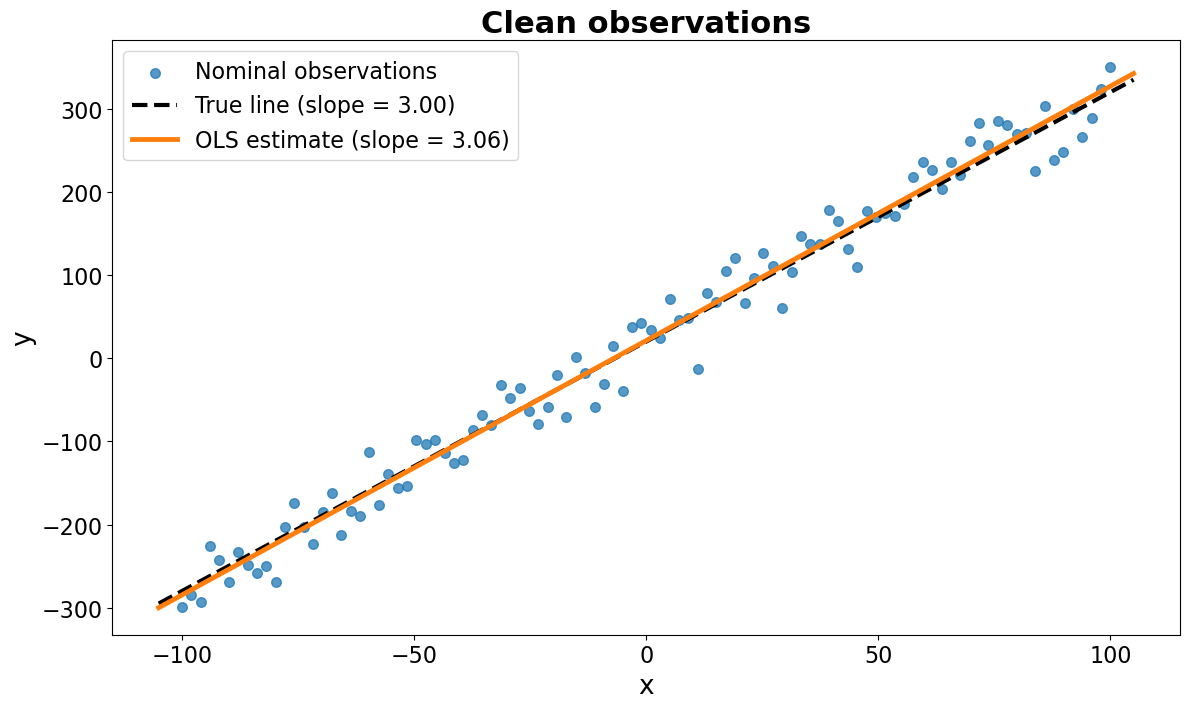

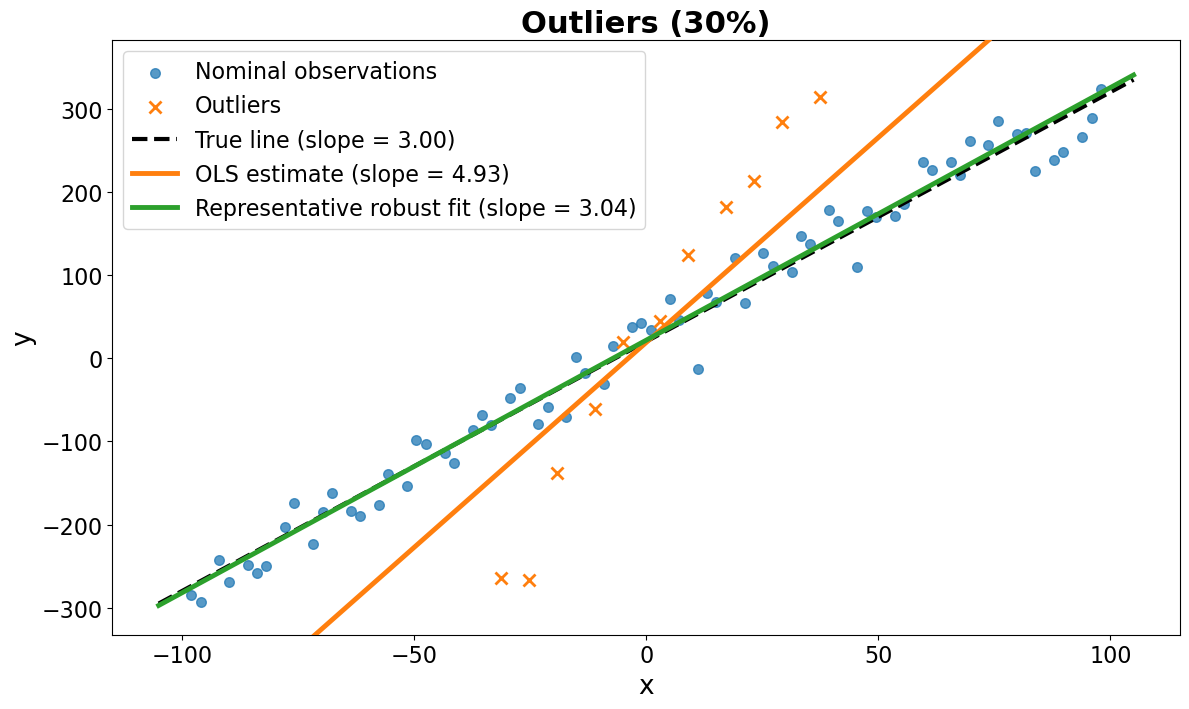


### Gaussian outliers with zero mean shift

$N=100$, $\sigma_{\mathrm{in}}^2=1000$, outlier-to-inlier variance
ratio 10, mean shift 0, contamination levels
$\{0,10,30,50,70,90\}\%$, and 30 Monte Carlo runs per box.


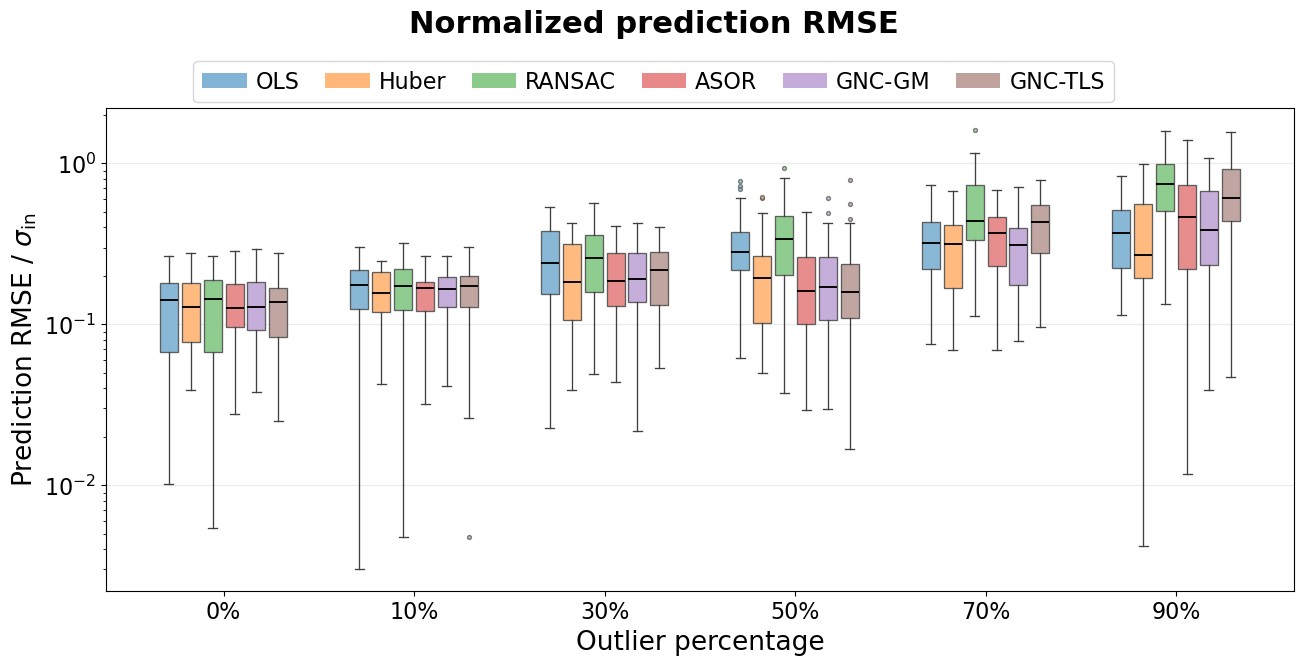


### Biased Gaussian outliers

$N=100$, $\sigma_{\mathrm{in}}^2=1000$, outlier-to-inlier variance
ratio 10, mean shift $3\sigma_{\mathrm{in}}$, contamination levels
$\{0,10,30,50,70,90\}\%$, and 30 Monte Carlo runs per box.


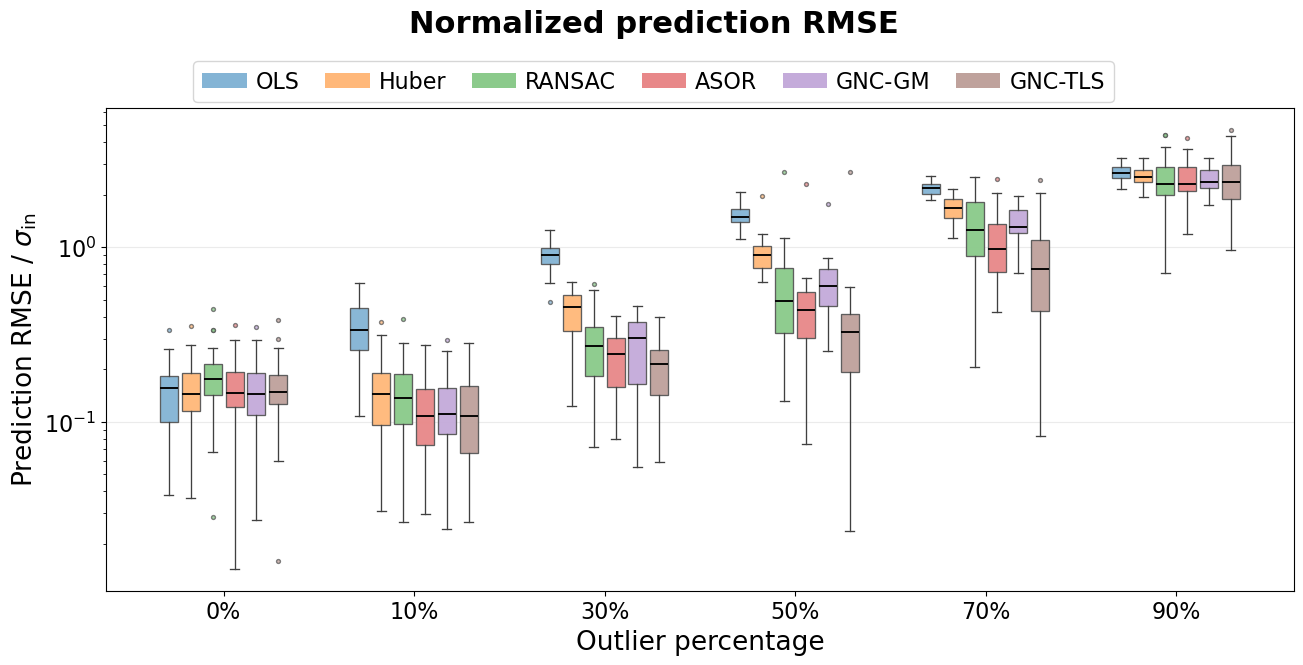


### Biased uniform outliers

$N=100$, $\sigma_{\mathrm{in}}^2=1000$, outlier-to-inlier variance
ratio 10, mean shift $3\sigma_{\mathrm{in}}$, contamination levels
$\{0,10,30,50,70,90\}\%$, and 30 Monte Carlo runs per box.


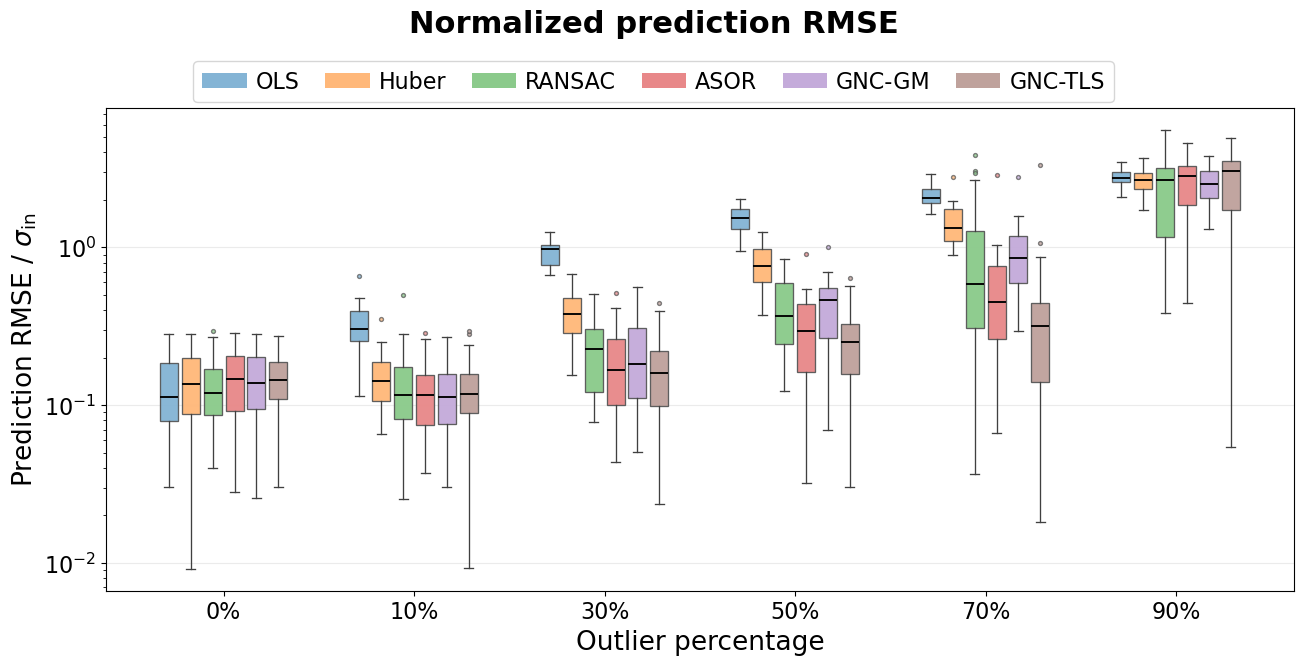


### Structured competing-line outliers

$N=100$, $\sigma_{\mathrm{in}}^2=1000$, outliers generated around
$y=20+15x$, contamination levels $\{0,10,30,50,70,90\}\%$, and
30 Monte Carlo runs per box.


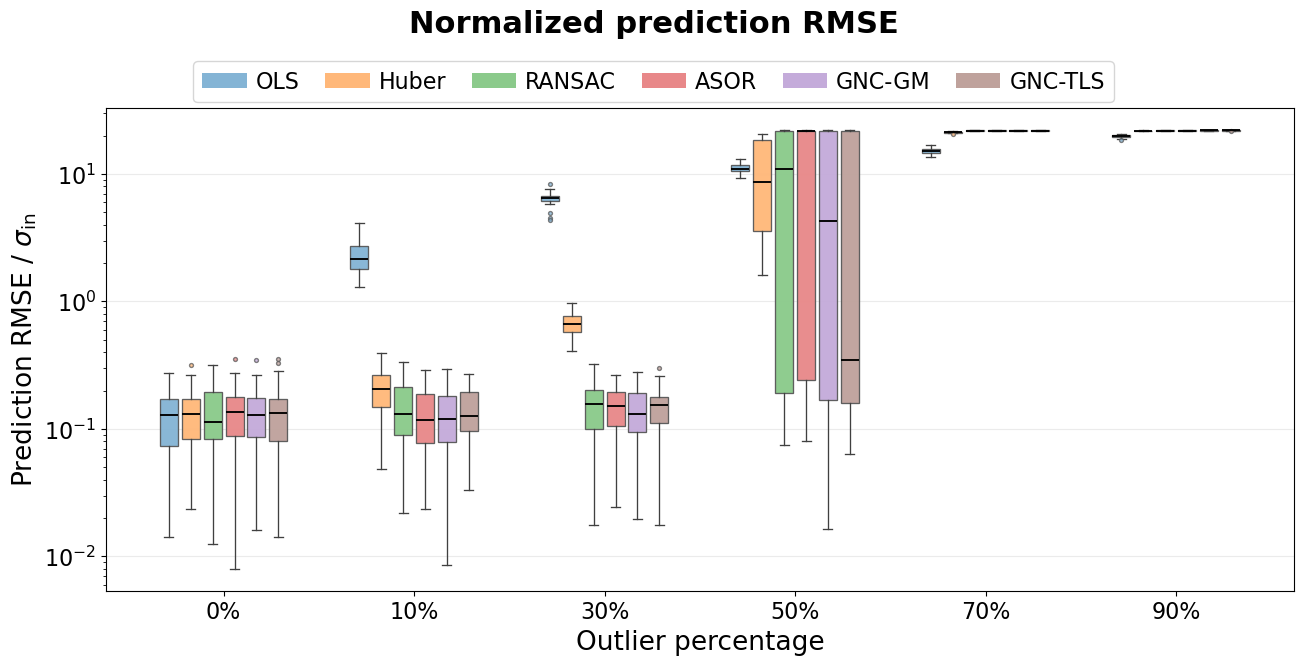

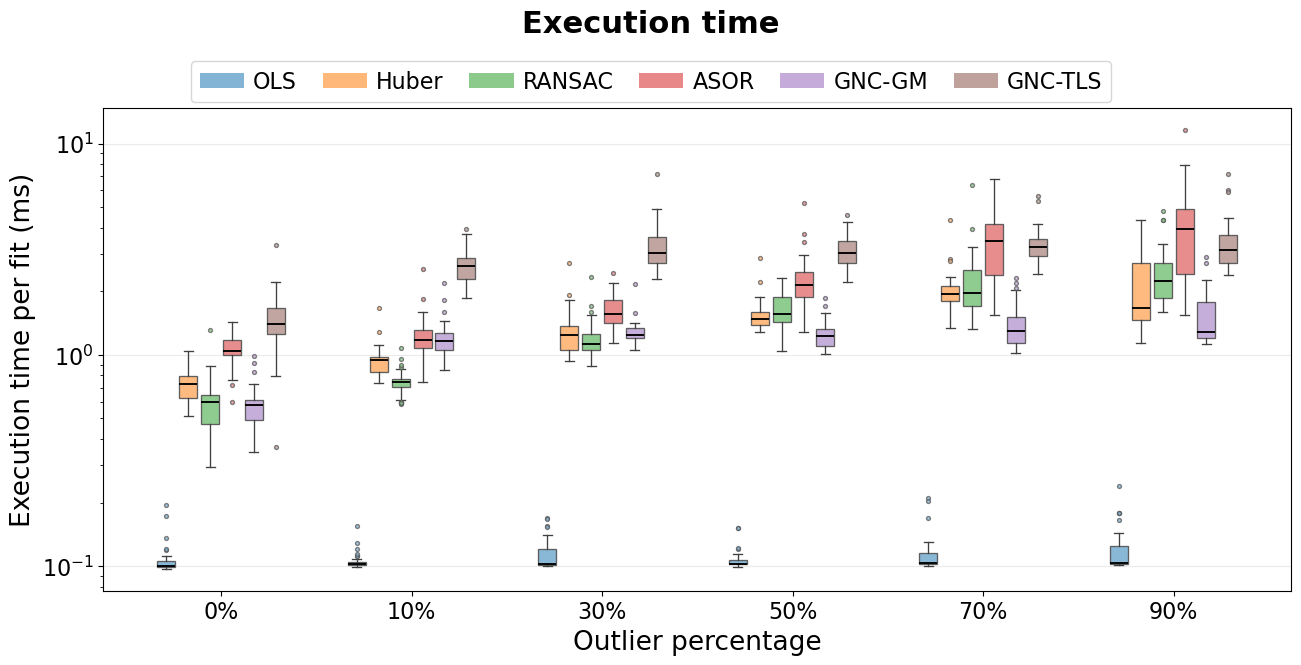


### Sample-size scaling

Gaussian outliers, 50% contamination,
$\sigma_{\mathrm{in}}^2=1000$, variance ratio 10, mean shift
$3\sigma_{\mathrm{in}}$, $N\in\{50,100,200,500,1000,2000,5000\}$,
and 30 Monte Carlo runs per box.


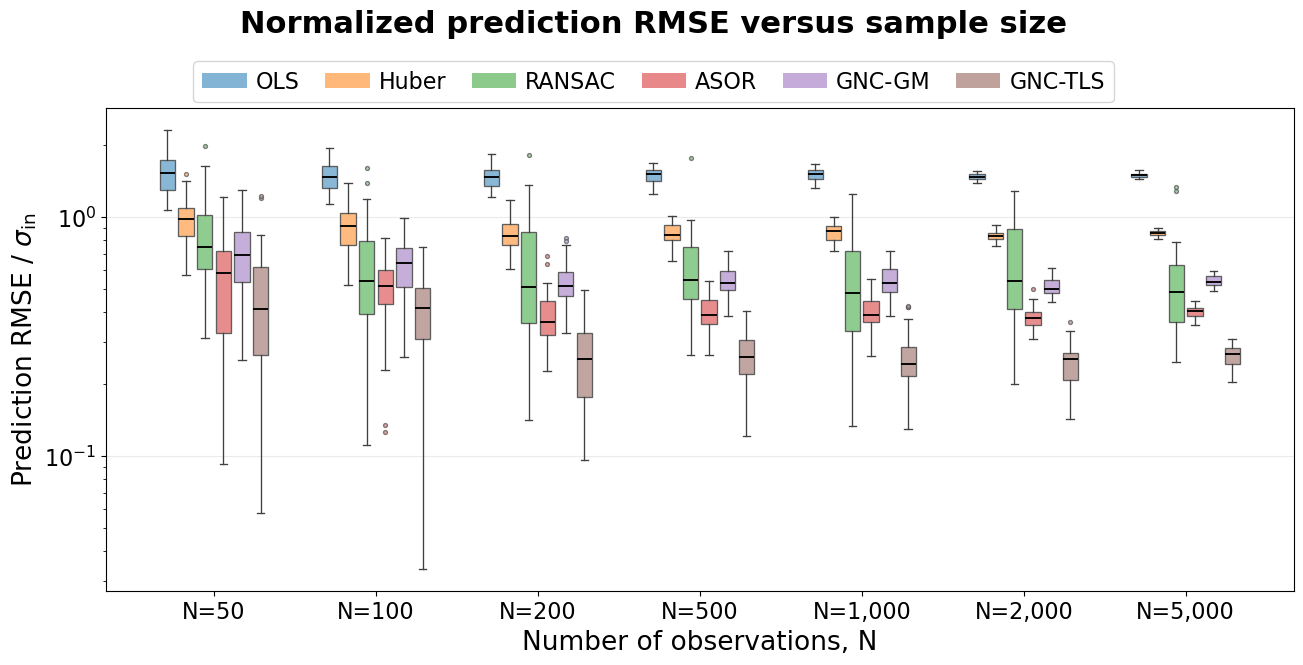

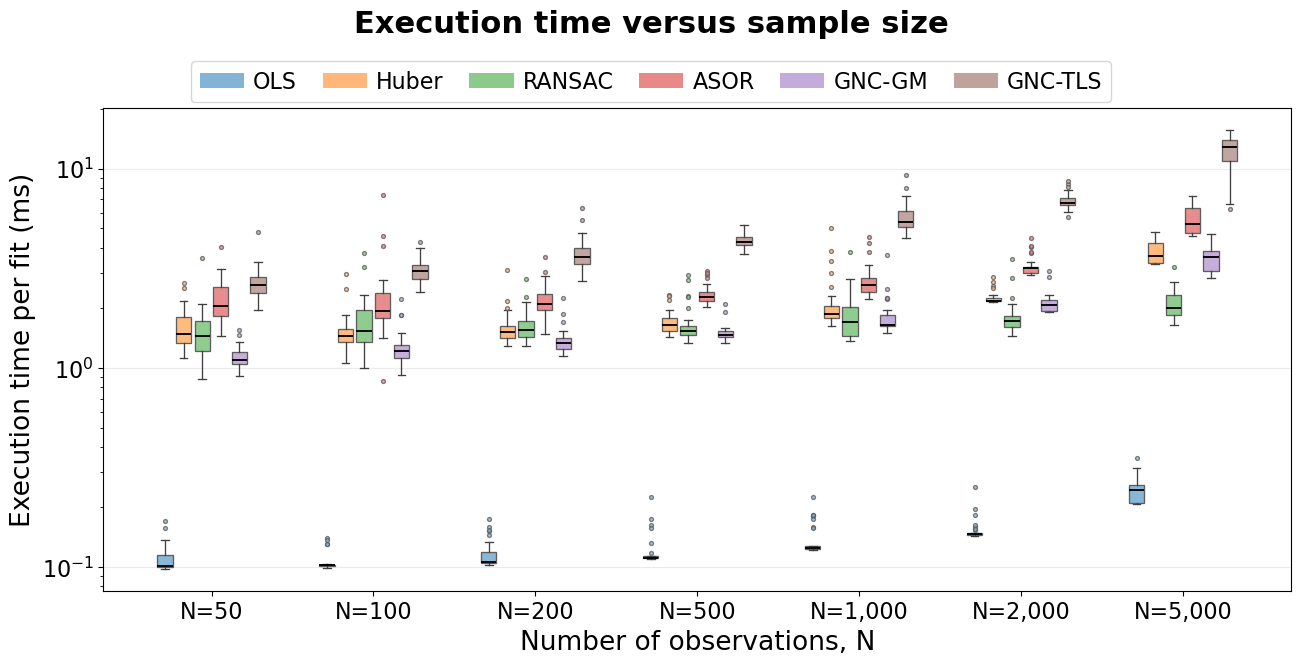

### Generated figure files

,figure_file,path
0,figure_1a_clean_observations.png,figures\figure_1a_clean_observations.png
1,figure_1b_biased_vertical_outliers.png,figures\figure_1b_biased_vertical_outliers.png
2,robust_gaussian_vr10_shift0_rmse.png,figures\robust_gaussian_vr10_shift0_rmse.png
3,robust_gaussian_vr10_shift3_rmse.png,figures\robust_gaussian_vr10_shift3_rmse.png
4,robust_uniform_vr10_shift3_rmse.png,figures\robust_uniform_vr10_shift3_rmse.png
5,structured_competing_line_rmse.png,figures\structured_competing_line_rmse.png
6,robust_gaussian_vr10_shift3_runtime.png,figures\robust_gaussian_vr10_shift3_runtime.png
7,scaling_gaussian_out50_rmse.png,figures\scaling_gaussian_out50_rmse.png
8,scaling_gaussian_out50_runtime.png,figures\scaling_gaussian_out50_runtime.png


In [15]:
from matplotlib.patches import Patch

METHOD_COLORS = {
    "OLS": "#84B4D5",
    "Huber": "#FFB87A",
    "RANSAC": "#8BCA8B",
    "ASOR": "#E88889",
    "GNC-GM": "#C4ABDA",
    "GNC-TLS": "#BFA29C",
}

METHOD_ORDER = [
    "OLS",
    "Huber",
    "RANSAC",
    "ASOR",
    "GNC-GM",
    "GNC-TLS",
]

# Typography retained from the earlier figures.
TITLE_FONTSIZE = 22
LABEL_FONTSIZE = 19
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 16

INTRO_FIGSIZE = (12, 7.2)
LINE_WIDTH = 2.5
SCATTER_SIZE = 48


def category_text(value, category: str) -> str:
    if category == "outlier_percent":
        return f"{float(value):g}%"
    if category == "n_samples":
        return f"N={int(value):,}"
    if category == "nominal_variance":
        return rf"$\sigma_{{\mathrm{{in}}}}^2={float(value):g}$"
    return str(value)


def selected_boxplot(
    data: pd.DataFrame,
    *,
    category: str,
    category_order: list,
    metric: str,
    title: str,
    y_label: str,
    output_filename: str,
    log_y: bool = True,
) -> Path:
    successful = data.loc[data["status"] == "success"].copy()

    group_centers = np.arange(len(category_order), dtype=float)
    box_width = 0.115
    offsets = (
        np.arange(len(METHOD_ORDER))
        - (len(METHOD_ORDER) - 1) / 2.0
    ) * box_width

    fig_width = max(13.2, 1.55 * len(category_order))
    fig, ax = plt.subplots(figsize=(fig_width, 6.8))

    for method_index, method in enumerate(METHOD_ORDER):
        arrays = []
        positions = []

        for group_index, category_value in enumerate(category_order):
            values = successful.loc[
                (successful[category] == category_value)
                & (successful["method"] == method),
                metric,
            ].dropna().to_numpy()

            if values.size == 0:
                raise ValueError(
                    f"No values for {method}, "
                    f"{category}={category_value}, metric={metric}."
                )

            arrays.append(values)
            positions.append(
                group_centers[group_index] + offsets[method_index]
            )

        box = ax.boxplot(
            arrays,
            positions=positions,
            widths=box_width * 0.82,
            patch_artist=True,
            showfliers=selected_cfg.show_fliers,
            whis=1.5,
            manage_ticks=False,
            medianprops={
                "color": "black",
                "linewidth": 1.35,
            },
            boxprops={
                "edgecolor": "0.35",
                "linewidth": 0.95,
            },
            whiskerprops={
                "color": "0.25",
                "linewidth": 0.95,
            },
            capprops={
                "color": "0.25",
                "linewidth": 0.95,
            },
            flierprops={
                "marker": "o",
                "markersize": 2.8,
                "markerfacecolor": METHOD_COLORS[method],
                "markeredgecolor": "0.35",
                "alpha": 0.75,
            },
        )

        for patch in box["boxes"]:
            patch.set_facecolor(METHOD_COLORS[method])
            patch.set_alpha(0.96)

    ax.set_xticks(group_centers)
    ax.set_xticklabels(
        [category_text(value, category) for value in category_order]
    )
    ax.set_xlabel(
        {
            "outlier_percent": "Outlier percentage",
            "n_samples": "Number of observations, N",
            "nominal_variance": (
                r"Nominal-noise variance, $\sigma_{\mathrm{in}}^2$"
            ),
        }[category],
        fontsize=LABEL_FONTSIZE,
    )
    ax.set_ylabel(y_label, fontsize=LABEL_FONTSIZE)
    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    if log_y:
        positive = successful.loc[successful[metric] > 0, metric]
        if not positive.empty:
            ax.set_yscale("log")

    legend_handles = [
        Patch(
            facecolor=METHOD_COLORS[method],
            edgecolor="none",
            label=method,
        )
        for method in METHOD_ORDER
    ]

    fig.suptitle(
        title,
        fontsize=TITLE_FONTSIZE,
        fontweight="bold",
        y=0.985,
    )
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.925),
        ncol=len(METHOD_ORDER),
        frameon=True,
        columnspacing=1.15,
        handlelength=2.0,
        handletextpad=0.4,
        fontsize=LEGEND_FONTSIZE,
    )
    fig.subplots_adjust(
        top=0.84,
        bottom=0.13,
        left=0.085,
        right=0.985,
    )

    output_path = figure_directory / output_filename
    fig.savefig(
        output_path,
        dpi=selected_cfg.dpi,
        bbox_inches="tight",
    )
    plt.show()
    return output_path


generated_figures: list[Path] = []

# ------------------------------------------------------------------
# Introductory figures
#
# These two plots are explanatory rather than benchmark conditions.
# The introductory alternative line uses slope 9 with nominal-scale
# noise so that the OLS slope distortion is clearly visible. This is an
# explanatory example; the structured benchmark below still uses slope 15.
# ------------------------------------------------------------------
intro_rng = np.random.default_rng(selected_cfg.base_seed + 700_000)
intro_n = selected_cfg.n_samples
intro_x = np.linspace(cfg.x_min, cfg.x_max, intro_n)
intro_X = np.column_stack((np.ones(intro_n), intro_x))

beta_true = np.array([cfg.intercept, cfg.slope], dtype=float)
beta_competing = np.array(
    [
        cfg.intercept,
        selected_cfg.introductory_competing_slope,
    ],
    dtype=float,
)

intro_true_line_values = intro_X @ beta_true
intro_competing_line_values = intro_X @ beta_competing
intro_sigma = np.sqrt(selected_cfg.nominal_variance)

intro_y_clean = (
    intro_true_line_values
    + intro_rng.normal(0.0, intro_sigma, intro_n)
)
intro_beta_ols_clean = np.linalg.lstsq(
    intro_X,
    intro_y_clean,
    rcond=None,
)[0]

intro_n_outliers = int(
    round(selected_cfg.introductory_outlier_ratio * intro_n)
)
# Spread the outliers across the full x-range so that their
# alternative slope produces a clear and reproducible OLS bias.
intro_outlier_indices = np.linspace(
    0,
    intro_n - 1,
    num=intro_n_outliers,
    dtype=int,
)
intro_outlier_indices = np.unique(intro_outlier_indices)
intro_n_outliers = intro_outlier_indices.size
intro_outlier_mask = np.zeros(intro_n, dtype=bool)
intro_outlier_mask[intro_outlier_indices] = True
intro_inlier_mask = ~intro_outlier_mask

intro_y_contaminated = intro_y_clean.copy()
intro_y_contaminated[intro_outlier_mask] = (
    intro_competing_line_values[intro_outlier_mask]
    + intro_rng.normal(
        0.0,
        intro_sigma * selected_cfg.introductory_outlier_noise_scale,
        intro_n_outliers,
    )
)
intro_beta_ols_contaminated = np.linalg.lstsq(
    intro_X,
    intro_y_contaminated,
    rcond=None,
)[0]

# Use one robust estimator internally to generate a method-neutral
# illustrative curve. The article labels this curve as a
# "Representative robust fit" because the introductory figure
# illustrates the general benefit of robust estimation rather than
# comparing or endorsing a particular method.
intro_robust_result = fit_gnc_tls_bhrsp(
    intro_x,
    intro_y_contaminated,
    intro_sigma,
    cfg,
)
intro_beta_robust = intro_robust_result.beta

intro_x_line = np.linspace(cfg.x_min - 5.0, cfg.x_max + 5.0, 500)
intro_X_line = np.column_stack(
    (np.ones_like(intro_x_line), intro_x_line)
)
intro_true_line = intro_X_line @ beta_true
intro_ols_clean_line = intro_X_line @ intro_beta_ols_clean
intro_ols_contaminated_line = (
    intro_X_line @ intro_beta_ols_contaminated
)
intro_robust_line = intro_X_line @ intro_beta_robust

# Determine the common y-axis limits from the clean-data figure only.
# Applying these same limits to both plots makes the slope distortion
# directly comparable, while extreme outliers outside the range are clipped.
intro_clean_y_values = np.concatenate(
    (
        intro_y_clean,
        intro_true_line,
        intro_ols_clean_line,
    )
)
intro_y_range = np.ptp(intro_clean_y_values)
intro_y_padding = 0.05 * intro_y_range if intro_y_range > 0 else 1.0
INTRO_COMMON_YLIM = (
    float(np.min(intro_clean_y_values) - intro_y_padding),
    float(np.max(intro_clean_y_values) + intro_y_padding),
)

fig, ax = plt.subplots(figsize=INTRO_FIGSIZE)
ax.scatter(
    intro_x,
    intro_y_clean,
    s=SCATTER_SIZE,
    alpha=0.75,
    label="Nominal observations",
)
ax.plot(
    intro_x_line,
    intro_true_line,
    linestyle="--",
    linewidth=LINE_WIDTH + 0.5,
    color="black",
    zorder=4,
    label=f"True line (slope = {beta_true[1]:.2f})",
)
ax.plot(
    intro_x_line,
    intro_ols_clean_line,
    linestyle="-",
    linewidth=LINE_WIDTH + 1.0,
    color="tab:orange",
    zorder=5,
    label=(
        f"OLS estimate "
        f"(slope = {intro_beta_ols_clean[1]:.2f})"
    ),
)
ax.set_title(
    "Clean observations",
    fontsize=TITLE_FONTSIZE,
    fontweight="bold",
)
ax.set_xlabel("x", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("y", fontsize=LABEL_FONTSIZE)
ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
ax.set_xlim(cfg.x_min - 15.0, cfg.x_max + 15.0)
ax.set_ylim(*INTRO_COMMON_YLIM)
ax.grid(alpha=0.0)
ax.legend(fontsize=LEGEND_FONTSIZE)
fig.tight_layout()

output_path = figure_directory / "figure_1a_clean_observations.png"
fig.savefig(
    output_path,
    dpi=selected_cfg.dpi,
    bbox_inches="tight",
)
plt.show()
generated_figures.append(output_path)

fig, ax = plt.subplots(figsize=INTRO_FIGSIZE)
ax.scatter(
    intro_x[intro_inlier_mask],
    intro_y_contaminated[intro_inlier_mask],
    s=SCATTER_SIZE,
    alpha=0.75,
    label="Nominal observations",
)
ax.scatter(
    intro_x[intro_outlier_mask],
    intro_y_contaminated[intro_outlier_mask],
    marker="x",
    s=75,
    linewidths=2.0,
    label="Outliers",
)
ax.plot(
    intro_x_line,
    intro_true_line,
    linestyle="--",
    linewidth=LINE_WIDTH + 0.5,
    color="black",
    zorder=4,
    label=f"True line (slope = {beta_true[1]:.2f})",
)
ax.plot(
    intro_x_line,
    intro_ols_contaminated_line,
    linestyle="-",
    linewidth=LINE_WIDTH + 1.0,
    color="tab:orange",
    zorder=5,
    label=(
        f"OLS estimate "
        f"(slope = {intro_beta_ols_contaminated[1]:.2f})"
    ),
)
ax.plot(
    intro_x_line,
    intro_robust_line,
    linestyle="-",
    linewidth=LINE_WIDTH + 1.0,
    color="tab:green",
    zorder=6,
    label=(
        f"Representative robust fit "
        f"(slope = {intro_beta_robust[1]:.2f})"
    ),
)
ax.set_title(
    "Outliers (30%)",
    fontsize=TITLE_FONTSIZE,
    fontweight="bold",
)
ax.set_xlabel("x", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("y", fontsize=LABEL_FONTSIZE)
ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
ax.set_xlim(cfg.x_min - 15.0, cfg.x_max + 15.0)
ax.set_ylim(*INTRO_COMMON_YLIM)
ax.grid(alpha=0.0)
ax.legend(fontsize=LEGEND_FONTSIZE)
fig.tight_layout()

output_path = (
    figure_directory / "figure_1b_biased_vertical_outliers.png"
)
fig.savefig(
    output_path,
    dpi=selected_cfg.dpi,
    bbox_inches="tight",
)
plt.show()
generated_figures.append(output_path)

# ------------------------------------------------------------------
# Robustness benchmark: zero-mean Gaussian replacement outliers
# ------------------------------------------------------------------
case = successful_results.loc[
    successful_results["condition_id"]
    == "robust_gaussian_vr10_shift0"
].copy()

display(
    Markdown(
        r"""
### Gaussian outliers with zero mean shift

$N=100$, $\sigma_{\mathrm{in}}^2=1000$, outlier-to-inlier variance
ratio 10, mean shift 0, contamination levels
$\{0,10,30,50,70,90\}\%$, and 30 Monte Carlo runs per box.
"""
    )
)

generated_figures.append(
    selected_boxplot(
        case,
        category="outlier_percent",
        category_order=sorted(case["outlier_percent"].unique()),
        metric="normalized_rmse",
        title="Normalized prediction RMSE",
        y_label=r"Prediction RMSE / $\sigma_{\mathrm{in}}$",
        output_filename="robust_gaussian_vr10_shift0_rmse.png",
        log_y=selected_cfg.rmse_log_scale,
    )
)

# ------------------------------------------------------------------
# Robustness benchmark: biased Gaussian replacement outliers
# ------------------------------------------------------------------
case = successful_results.loc[
    successful_results["condition_id"]
    == "robust_gaussian_vr10_shift3"
].copy()

display(
    Markdown(
        r"""
### Biased Gaussian outliers

$N=100$, $\sigma_{\mathrm{in}}^2=1000$, outlier-to-inlier variance
ratio 10, mean shift $3\sigma_{\mathrm{in}}$, contamination levels
$\{0,10,30,50,70,90\}\%$, and 30 Monte Carlo runs per box.
"""
    )
)

generated_figures.append(
    selected_boxplot(
        case,
        category="outlier_percent",
        category_order=sorted(case["outlier_percent"].unique()),
        metric="normalized_rmse",
        title="Normalized prediction RMSE",
        y_label=r"Prediction RMSE / $\sigma_{\mathrm{in}}$",
        output_filename="robust_gaussian_vr10_shift3_rmse.png",
        log_y=selected_cfg.rmse_log_scale,
    )
)

# ------------------------------------------------------------------
# Robustness benchmark: biased uniform replacement outliers
# ------------------------------------------------------------------
uniform_case = successful_results.loc[
    successful_results["condition_id"]
    == "robust_uniform_vr10_shift3"
].copy()

display(
    Markdown(
        r"""
### Biased uniform outliers

$N=100$, $\sigma_{\mathrm{in}}^2=1000$, outlier-to-inlier variance
ratio 10, mean shift $3\sigma_{\mathrm{in}}$, contamination levels
$\{0,10,30,50,70,90\}\%$, and 30 Monte Carlo runs per box.
"""
    )
)

generated_figures.append(
    selected_boxplot(
        uniform_case,
        category="outlier_percent",
        category_order=sorted(uniform_case["outlier_percent"].unique()),
        metric="normalized_rmse",
        title="Normalized prediction RMSE",
        y_label=r"Prediction RMSE / $\sigma_{\mathrm{in}}$",
        output_filename="robust_uniform_vr10_shift3_rmse.png",
        log_y=selected_cfg.rmse_log_scale,
    )
)

# ------------------------------------------------------------------
# Robustness benchmark: coherent competing-line outliers
# ------------------------------------------------------------------
structured_case = successful_results.loc[
    successful_results["condition_id"]
    == "structured_competing_line_slope15"
].copy()

display(
    Markdown(
        r"""
### Structured competing-line outliers

$N=100$, $\sigma_{\mathrm{in}}^2=1000$, outliers generated around
$y=20+15x$, contamination levels $\{0,10,30,50,70,90\}\%$, and
30 Monte Carlo runs per box.
"""
    )
)

generated_figures.append(
    selected_boxplot(
        structured_case,
        category="outlier_percent",
        category_order=sorted(
            structured_case["outlier_percent"].unique()
        ),
        metric="normalized_rmse",
        title="Normalized prediction RMSE",
        y_label=r"Prediction RMSE / $\sigma_{\mathrm{in}}$",
        output_filename="structured_competing_line_rmse.png",
        log_y=selected_cfg.rmse_log_scale,
    )
)

generated_figures.append(
    selected_boxplot(
        case,
        category="outlier_percent",
        category_order=sorted(case["outlier_percent"].unique()),
        metric="runtime_ms",
        title="Execution time",
        y_label="Execution time per fit (ms)",
        output_filename="robust_gaussian_vr10_shift3_runtime.png",
        log_y=selected_cfg.runtime_log_scale,
    )
)

# ------------------------------------------------------------------
# Sample-size scaling under biased Gaussian contamination
# ------------------------------------------------------------------
case = successful_results.loc[
    successful_results["condition_id"]
    == "scaling_gaussian_out50"
].copy()

display(
    Markdown(
        r"""
### Sample-size scaling

Gaussian outliers, 50% contamination,
$\sigma_{\mathrm{in}}^2=1000$, variance ratio 10, mean shift
$3\sigma_{\mathrm{in}}$, $N\in\{50,100,200,500,1000,2000,5000\}$,
and 30 Monte Carlo runs per box.
"""
    )
)

generated_figures.append(
    selected_boxplot(
        case,
        category="n_samples",
        category_order=sorted(case["n_samples"].unique()),
        metric="normalized_rmse",
        title="Normalized prediction RMSE versus sample size",
        y_label=r"Prediction RMSE / $\sigma_{\mathrm{in}}$",
        output_filename="scaling_gaussian_out50_rmse.png",
        log_y=selected_cfg.rmse_log_scale,
    )
)

generated_figures.append(
    selected_boxplot(
        case,
        category="n_samples",
        category_order=sorted(case["n_samples"].unique()),
        metric="runtime_ms",
        title="Execution time versus sample size",
        y_label="Execution time per fit (ms)",
        output_filename="scaling_gaussian_out50_runtime.png",
        log_y=selected_cfg.runtime_log_scale,
    )
)

generated_names = [path.name for path in generated_figures]

if generated_names != required_figure_files:
    raise RuntimeError(
        "Generated figure filenames do not match the required list.\n"
        f"Expected: {required_figure_files}\n"
        f"Generated: {generated_names}"
    )

figure_manifest = pd.DataFrame(
    {
        "figure_file": generated_names,
        "path": [str(path) for path in generated_figures],
    }
)

display(Markdown("### Generated figure files"))
display(figure_manifest)


## 9. Export numerical results, article tables, and figure manifest


In [16]:
if selected_cfg.save_csv:
    results_path = figure_directory / "selected_experiment_results.csv"
    summary_path = figure_directory / "selected_method_summary.csv"
    manifest_path = figure_directory / "selected_figure_manifest.csv"
    accuracy_table_path = figure_directory / "accuracy_at_50_percent.csv"
    runtime_table_path = figure_directory / "runtime_at_50_percent.csv"
    noise_table_path = figure_directory / "noise_sensitivity_table.csv"

    all_results.to_csv(results_path, index=False)
    selected_summary.to_csv(summary_path, index=False)
    figure_manifest.to_csv(manifest_path, index=False)
    accuracy_table_50.to_csv(accuracy_table_path)
    runtime_table_50.to_csv(runtime_table_path)
    noise_sensitivity_table.to_csv(noise_table_path)

    print("Saved:", results_path)
    print("Saved:", summary_path)
    print("Saved:", manifest_path)
    print("Saved:", accuracy_table_path)
    print("Saved:", runtime_table_path)
    print("Saved:", noise_table_path)


Saved: figures\selected_experiment_results.csv
Saved: figures\selected_method_summary.csv
Saved: figures\selected_figure_manifest.csv
Saved: figures\accuracy_at_50_percent.csv
Saved: figures\runtime_at_50_percent.csv
Saved: figures\noise_sensitivity_table.csv


The notebook generates the nine retained PNG figures and exports the
complete numerical results, article tables, and figure manifest. The
introductory alternative line uses slope \(9\), whereas the structured
benchmark uses the actual competing slope \(15\).

Before publishing updated runtime numbers, restart the kernel and run all
cells once on the stated benchmark system. Runtime values should then be
copied from the exported CSV files without rerunning the notebook.
